In [1]:
import glob

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import pickle

In [ ]:
MODEL_PATH = r"..\..\YOLO.pt"
model = YOLO(MODEL_PATH)

image_paths = sorted(glob.glob(r"..\..\data\images\data_5_*.jpg"))

In [3]:
df1 = pd.DataFrame(columns=["image", "tank_h", "water_h"])
print(df1)

Empty DataFrame
Columns: [image, tank_h, water_h]
Index: []


In [4]:
for i, image in enumerate(image_paths, start=1):
    r0 = model(image)[0]

    name_to_id = {v: k for k, v in r0.names.items()}
    tank_id = name_to_id.get("Tank")
    water_id = name_to_id.get("Water")
    detected_water = (r0.obb.cls.int() == water_id).any().item()
    detected_tank  = (r0.obb.cls.int() == tank_id).any().item()

    all_tank_rows = np.where(r0.obb.cls == tank_id)[0]
    all_water_rows = np.where(r0.obb.cls == water_id)[0]

    tank_conf = r0.obb.conf[all_tank_rows]
    water_conf = r0.obb.conf[all_water_rows]

    if detected_tank:
        tank_row = np.where(r0.obb.conf == max(tank_conf))[0]
        tank_h = r0.obb.xywhr[tank_row,3]
    else:
        tank_h = None

    if detected_water:
        water_row = np.where(r0.obb.conf == max(water_conf))[0]
        water_h = r0.obb.xywhr[water_row,3]
    else:
        water_h = torch.tensor(0)

    new_row = {"image": image, "tank_h": tank_h, "water_h": water_h}
    df1.loc[len(df1)] = new_row


image 1/1 c:\Users\mccha\OneDrive\Desktop\three_tank_control\etc\inference_linear_reg\..\..\data\images\data_5_1_0016.jpg: 384x640 1 Tank, 1 Water, 88.9ms
Speed: 4.8ms preprocess, 88.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\mccha\OneDrive\Desktop\three_tank_control\etc\inference_linear_reg\..\..\data\images\data_5_1_0017.jpg: 384x640 1 Tank, 1 Water, 26.9ms
Speed: 2.0ms preprocess, 26.9ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\mccha\OneDrive\Desktop\three_tank_control\etc\inference_linear_reg\..\..\data\images\data_5_1_0018.jpg: 384x640 1 Tank, 1 Water, 18.9ms
Speed: 1.2ms preprocess, 18.9ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\mccha\OneDrive\Desktop\three_tank_control\etc\inference_linear_reg\..\..\data\images\data_5_1_0019.jpg: 384x640 1 Tank, 1 Water, 19.1ms
Speed: 1.0ms preprocess, 19.1ms inference, 0.1ms postprocess per image at shape (1, 3

In [5]:
print(df1.head(), df1.shape)

                                 image              tank_h             water_h
0  ..\..\data\images\data_5_1_0016.jpg  [tensor(724.9415)]  [tensor(684.8481)]
1  ..\..\data\images\data_5_1_0017.jpg  [tensor(724.6931)]  [tensor(683.0660)]
2  ..\..\data\images\data_5_1_0018.jpg  [tensor(724.6537)]  [tensor(698.6919)]
3  ..\..\data\images\data_5_1_0019.jpg  [tensor(723.7654)]  [tensor(718.9155)]
4  ..\..\data\images\data_5_1_0020.jpg  [tensor(723.3724)]  [tensor(714.4650)] (236, 3)


In [ ]:
df1.to_csv(r"..\..\data\util\linear_regression_data.csv", index=False, encoding="utf-8-sig")

In [ ]:
df2 = pd.read_excel(r"..\..\data\util\linear_regression_true.xlsx")
print(df2.head(), df2.shape)

                                 image  true_h
0  ..\..\data\images\data_5_1_0016.jpg     8.4
1  ..\..\data\images\data_5_1_0017.jpg     8.4
2  ..\..\data\images\data_5_1_0018.jpg     8.4
3  ..\..\data\images\data_5_1_0019.jpg     8.4
4  ..\..\data\images\data_5_1_0020.jpg     8.3 (236, 2)


In [8]:
df = pd.merge(df1, df2)
print(df.head(), df.shape)

                                 image              tank_h  \
0  ..\..\data\images\data_5_1_0016.jpg  [tensor(724.9415)]   
1  ..\..\data\images\data_5_1_0017.jpg  [tensor(724.6931)]   
2  ..\..\data\images\data_5_1_0018.jpg  [tensor(724.6537)]   
3  ..\..\data\images\data_5_1_0019.jpg  [tensor(723.7654)]   
4  ..\..\data\images\data_5_1_0020.jpg  [tensor(723.3724)]   

              water_h  true_h  
0  [tensor(684.8481)]     8.4  
1  [tensor(683.0660)]     8.4  
2  [tensor(698.6919)]     8.4  
3  [tensor(718.9155)]     8.4  
4  [tensor(714.4650)]     8.3   (236, 4)


In [9]:
df = df.dropna(subset=["tank_h", "true_h"]).reset_index(drop=True)
print(df.head(), df.shape)

                                 image              tank_h  \
0  ..\..\data\images\data_5_1_0016.jpg  [tensor(724.9415)]   
1  ..\..\data\images\data_5_1_0017.jpg  [tensor(724.6931)]   
2  ..\..\data\images\data_5_1_0018.jpg  [tensor(724.6537)]   
3  ..\..\data\images\data_5_1_0019.jpg  [tensor(723.7654)]   
4  ..\..\data\images\data_5_1_0020.jpg  [tensor(723.3724)]   

              water_h  true_h  
0  [tensor(684.8481)]     8.4  
1  [tensor(683.0660)]     8.4  
2  [tensor(698.6919)]     8.4  
3  [tensor(718.9155)]     8.4  
4  [tensor(714.4650)]     8.3   (236, 4)


In [10]:
df["normalised_h"] = df["water_h"]/df["tank_h"]
print(df.head(), df.shape)

                                 image              tank_h  \
0  ..\..\data\images\data_5_1_0016.jpg  [tensor(724.9415)]   
1  ..\..\data\images\data_5_1_0017.jpg  [tensor(724.6931)]   
2  ..\..\data\images\data_5_1_0018.jpg  [tensor(724.6537)]   
3  ..\..\data\images\data_5_1_0019.jpg  [tensor(723.7654)]   
4  ..\..\data\images\data_5_1_0020.jpg  [tensor(723.3724)]   

              water_h  true_h      normalised_h  
0  [tensor(684.8481)]     8.4  [tensor(0.9447)]  
1  [tensor(683.0660)]     8.4  [tensor(0.9426)]  
2  [tensor(698.6919)]     8.4  [tensor(0.9642)]  
3  [tensor(718.9155)]     8.4  [tensor(0.9933)]  
4  [tensor(714.4650)]     8.3  [tensor(0.9877)]   (236, 5)


In [11]:
normalised_h = np.array(df["normalised_h"].apply(lambda x: x[0].item()).values)
true_h = df["true_h"]
print(max(normalised_h), max(true_h))
print(normalised_h.dtype, true_h.dtype)

0.9932990670204163 8.4
float64 float64


(0.0, 9.0)

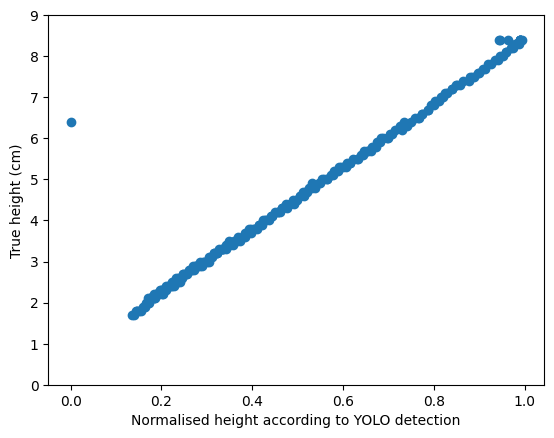

In [12]:
plt.scatter(normalised_h, true_h)
plt.xlabel("Normalised height according to YOLO detection")
plt.ylabel("True height (cm)")
plt.ylim((0,9))

In [13]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

X = df["normalised_h"].to_numpy().reshape(-1, 1)
y = df["true_h"].to_numpy()

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    residual_threshold=1,   # cm 단위로 조절 (데이터 스케일에 맞게)
    random_state=0
)
ransac.fit(X, y)

inlier_mask = ransac.inlier_mask_
df_clean = df[inlier_mask].reset_index(drop=True)

In [14]:
print(df_clean.head(), df_clean.shape)

                                 image              tank_h  \
0  ..\..\data\images\data_5_1_0016.jpg  [tensor(724.9415)]   
1  ..\..\data\images\data_5_1_0017.jpg  [tensor(724.6931)]   
2  ..\..\data\images\data_5_1_0018.jpg  [tensor(724.6537)]   
3  ..\..\data\images\data_5_1_0019.jpg  [tensor(723.7654)]   
4  ..\..\data\images\data_5_1_0020.jpg  [tensor(723.3724)]   

              water_h  true_h      normalised_h  
0  [tensor(684.8481)]     8.4  [tensor(0.9447)]  
1  [tensor(683.0660)]     8.4  [tensor(0.9426)]  
2  [tensor(698.6919)]     8.4  [tensor(0.9642)]  
3  [tensor(718.9155)]     8.4  [tensor(0.9933)]  
4  [tensor(714.4650)]     8.3  [tensor(0.9877)]   (235, 5)


(0.0, 1.1)

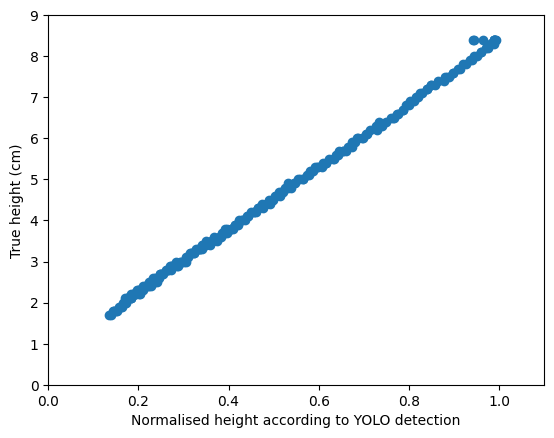

In [15]:
normalised_h = np.array(df_clean["normalised_h"].apply(lambda x: x[0].item()).values)
true_h = df_clean["true_h"]
plt.scatter(normalised_h, true_h)
plt.xlabel("Normalised height according to YOLO detection")
plt.ylabel("True height (cm)")
plt.ylim((0,9))
plt.xlim((0, 1.1))

In [16]:
coef = ransac.estimator_.coef_[0]
intercept = ransac.estimator_.intercept_
print("Slope:", coef)
print("Intercept:", intercept)

Slope: 7.701273019117101
Intercept: 0.7084194867553455


Text(0, 0.5, 'True height (cm)')

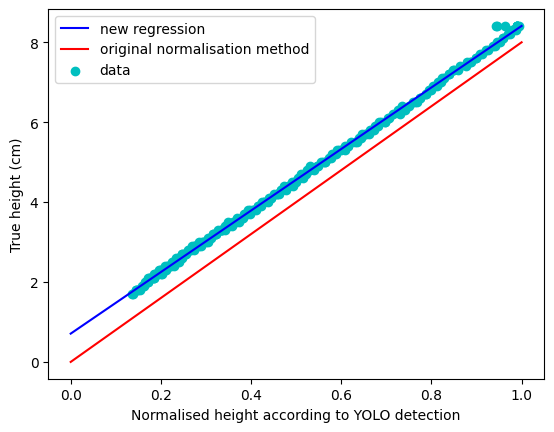

In [17]:
x = np.linspace(0,1,1000)
y1 = coef*x + intercept
y2 = x*8

plt.plot(x,y1, c="b", label="new regression")
plt.plot(x,y2, c="r", label="original normalisation method")
plt.scatter(normalised_h, true_h, c="c", label="data")
plt.legend()
plt.xlabel("Normalised height according to YOLO detection")
plt.ylabel("True height (cm)")

In [18]:
outlier_mask = ~inlier_mask
df_outliers = df.loc[outlier_mask]

print(df_outliers)
print("날아간 행 개수:", outlier_mask.sum())
print("원본 인덱스:", df.index[outlier_mask].tolist())

outlier_idx = df.index[~inlier_mask]
df = df.drop(index=outlier_idx).reset_index(drop=True)

                                  image              tank_h    water_h  \
24  ..\..\data\images\data_5_1_0040.jpg  [tensor(726.0405)]  tensor(0)   

    true_h  normalised_h  
24     6.4  [tensor(0.)]  
날아간 행 개수: 1
원본 인덱스: [24]


In [19]:
true = df["true_h"]

new_pred = coef*normalised_h + intercept
new_abserr = np.abs(new_pred - true)
new_mae = np.mean(new_abserr)

prev_pred = normalised_h*8
prev_abserr = np.abs(prev_pred - true)
prev_mae = np.mean(prev_abserr)

print(f"new regression mae: {new_mae}\nprevious normalisation mae: {prev_mae}")
print(f"new regression maximum and minimm absolute error: {new_abserr.max(), new_abserr.min()}\nprevious normalisation maximum and minimm absolute error: {prev_abserr.max(), prev_abserr.min()}")

new regression mae: 0.04556451779860736
previous normalisation mae: 0.5599602258966323
new regression maximum and minimm absolute error: (np.float64(0.43267628812312164), np.float64(0.00019635271050599812))
previous normalisation maximum and minimm absolute error: (np.float64(0.8595279693603519), np.float64(0.3592149734497072))


In [20]:
param = {"grad": coef,
         "int": intercept}

with open(r"..\..\linear_regression_param.pickle", "wb") as f:
    pickle.dump(param, f)